# 1차 분석 (RQ1) — 이탈 잠재 고객은 얼마나 되는가?

**사용 컬럼:** 기준년월, 법인ID, 요구불입금금액 (3개)

**병합 내용**

| 출처 | 가져온 것 |
|---|---|
| 우리 기획 | 전년 동월 3개월 비교(입금 YoY), −30% 기준, 기준값 민감도, 신뢰구간, 법인 단위 요약 |
| 사전분석 (validation) | 최소 기준선(직전 평균 10백만원), 증가 신호 대조군, 월별 **발생률**(신호 ÷ 위험집합), 신호 후 6개월 추적 → 이탈/회복/지속저조, 계절성 명시 판정, 월 편중 점검, 법인ID 비노출 |
| 새로 보완 | 이탈 판정을 **관측 종료 또는 입금 0이 3개월 연속**으로 확장 (빈 달이 없는 데이터에서도 작동), 다른 모듈 없이 단독 실행 |

**실행:** 위에서부터 셀을 차례로 실행 (Shift+Enter). 설정은 첫 코드 셀에서만 바꾸면 됩니다.

## 0. 설정

In [ ]:
from pathlib import Path

DATA_PATH = Path()   # 원본 경로 (.xlsx 또는 .csv) 분석 데이터 여기에 넣으시오
SHEET_NAME = 0              # 시트가 여러 개로 나뉘어 있으면 None (전부 합침)
CACHE_PATH = Path("data/interim/rq1_cache.pkl")   # 원본을 바꾸면 이 파일 삭제
OUTPUT_DIR = Path("output/rq1")

THETA = 0.30                # 감소 신호: 입금 YoY ≤ −30% (증가 신호는 ≥ +30%)
THETA_LIST = [0.20, 0.30, 0.50]     # 기준값 민감도
BASELINE = 10.0             # 작년 같은 3개월 평균 입금이 10백만원 미만이면 판정 제외 (반올림 노이즈 차단)
BASELINE_LIST = [0.0, 10.0]         # 기준선 민감도 (0 = 기준선 없음)
FOLLOW = 6                  # 신호 후 추적 개월 수
CHURN_WIN = 3               # 이탈: 신호 후 3개월 안에 관측 종료 또는 입금 0이 3개월 연속
RECOVERY_RATIO = 0.70       # 회복: 신호 후 3개월 평균 입금이 작년 기준 평균의 70% 이상

SAVE_FIRM_LABEL = False     # True면 법인별 라벨 CSV 저장 (법인ID 포함 → 외부 공유 금지)

KEY_MONTH, KEY_ID, INFLOW = "기준년월", "법인ID", "요구불입금금액"

<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\vvvip\AppData\Local\Temp\ipykernel_28916\567247311.py:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  DATA_PATH = Path("C:\pythonim\im뱅크 프로젝트1\(iM뱅크) 2026 교육용 법인 익명데이터.xlsx")   # 원본 경로 (.xlsx 또는 .csv)


## 1. 라이브러리 · 공통 함수

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _name in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _name in _fonts:
        plt.rcParams["font.family"] = _name
        break
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


def wilson_ci(k, n, z=1.96):
    """비율의 95% 신뢰구간 (Wilson)."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h


def rate_row(label, k, n, **extra):
    lo, hi = wilson_ci(k, n)
    return {"구분": label, "수": int(k), "분모": int(n), "비율": k / n if n else np.nan,
            "95% CI 하한": lo, "95% CI 상한": hi, **extra}


def max_min_ratio(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or x.min() == 0:
        return np.nan
    return x.max() / x.min()


results, log = {}, []

def note(label, value):
    log.append({"항목": label, "값": value})
    print(f"  · {label}: {value}")

## 2. 데이터 불러오기 · 정리

- 3개 컬럼만 읽고, 처음 한 번 읽은 뒤에는 캐시를 사용합니다.
- **법인ID는 읽자마자 내부 번호로 바꿔** 이후 출력·저장 결과에 나오지 않게 합니다 (사전분석 보안 원칙).

In [3]:
if CACHE_PATH.exists():
    raw = pd.read_pickle(CACHE_PATH)
else:
    cols = [KEY_MONTH, KEY_ID, INFLOW]
    if DATA_PATH.suffix.lower() == ".csv":
        try:
            raw = pd.read_csv(DATA_PATH, usecols=cols, dtype=str, encoding="utf-8-sig")
        except UnicodeDecodeError:
            raw = pd.read_csv(DATA_PATH, usecols=cols, dtype=str, encoding="cp949")
    else:
        raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, usecols=cols, dtype=str)
        if isinstance(raw, dict):
            raw = pd.concat(raw.values(), ignore_index=True)
    raw.to_pickle(CACHE_PATH)

print("[데이터 정리]")
note("원본 행 수", len(raw))
df = pd.DataFrame()
df["corp"] = pd.Categorical(raw[KEY_ID].astype(str).str.strip())
digits = raw[KEY_MONTH].astype(str).str.replace(r"\D", "", regex=True).str[:6]
df["ym"] = pd.to_datetime(digits, format="%Y%m", errors="coerce").dt.to_period("M")
df["inflow"] = pd.to_numeric(raw[INFLOW].astype(str).str.replace(",", "").str.strip(), errors="coerce")

note("기준년월 변환 실패 (제외)", int(df["ym"].isna().sum()))
note("입금액 결측·변환 실패", int(df["inflow"].isna().sum()))
note("음수 입금액 (결측 처리)", int((df["inflow"] < 0).sum()))
df.loc[df["inflow"] < 0, "inflow"] = np.nan
df = df.dropna(subset=["ym"])
note("(법인, 기준년월) 중복 (첫 행만 유지)", int(df.duplicated(["corp", "ym"]).sum()))
df = df.drop_duplicates(["corp", "ym"])

[데이터 정리]
  · 원본 행 수: 365988
  · 기준년월 변환 실패 (제외): 0
  · 입금액 결측·변환 실패: 0
  · 음수 입금액 (결측 처리): 0
  · (법인, 기준년월) 중복 (첫 행만 유지): 0


## 3. 법인 × 월 배열 만들기

- `P[법인, 월]` = 기록 있음(1) / 없음(0), `X[법인, 월]` = 요구불입금금액 (기록 없는 달은 빈칸)
- **데이터 구조 확인:** 빈 달이 있는 데이터인지, 매달 줄이 있고 거래가 없으면 0으로 들어가는 데이터인지 봅니다. 이탈 판정 방식에 영향을 줍니다.

In [4]:
months = pd.period_range(df["ym"].min(), df["ym"].max(), freq="M")
n_corp, n_month = len(df["corp"].cat.categories), len(months)
ci = df["corp"].cat.codes.to_numpy()
mi = ((df["ym"].dt.year - months[0].year) * 12 + (df["ym"].dt.month - months[0].month)).to_numpy()

P = np.zeros((n_corp, n_month), dtype=bool)
X = np.full((n_corp, n_month), np.nan)
P[ci, mi] = True
X[ci, mi] = df["inflow"].to_numpy()

note("기간", f"{months[0]} ~ {months[-1]} ({n_month}개월)")
note("법인 수", n_corp)
full = P.all(axis=1).mean()
note("전 기간 기록이 있는 법인 비율", f"{full:.1%}")
note("기록 없는 칸 비율", f"{1 - P.mean():.1%}")
note("입금 0인 칸 비율 (기록 있는 칸 중)", f"{(X[P] == 0).mean():.1%}")
if full > 0.99:
    print("  → 빈 달이 거의 없는 데이터입니다. 이탈은 주로 '입금 0이 3개월 연속'으로 잡힙니다.")

  · 기간: 2023-01 ~ 2025-12 (36개월)
  · 법인 수: 15473
  · 전 기간 기록이 있는 법인 비율: 21.8%
  · 기록 없는 칸 비율: 34.3%
  · 입금 0인 칸 비율 (기록 있는 칸 중): 10.8%


## 4. 계절성 점검 — 전년 동월 비교가 필요한가

사전분석과 같은 방식: 연도별로 정규화한 월 지수를 만들고, **연도 간 평균 상관 ≥ 0.5 이고 최대월/최소월 지수비 ≥ 1.3**이면 "계절성 있음"으로 판정합니다.

  · 평균: 연도간 평균상관 0.213, 최대/최소 지수비 1.310 → 계절성 없음
  · 중앙값: 연도간 평균상관 0.805, 최대/최소 지수비 1.483 → 계절성 있음


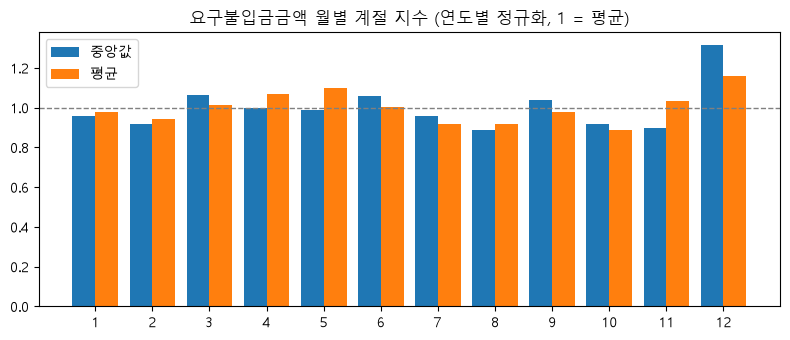

In [5]:
rows = []
for j, m in enumerate(months):
    v = X[P[:, j], j]
    v = v[np.isfinite(v)]
    rows.append({"연도": m.year, "월": m.month, "평균": v.mean() if v.size else np.nan,
                 "중앙값": np.median(v) if v.size else np.nan})
mon = pd.DataFrame(rows)

season_rows, verdicts = [], []
for stat in ["평균", "중앙값"]:
    piv = mon.pivot(index="연도", columns="월", values=stat)
    r = piv.div(piv.mean(axis=1), axis=0)          # 연도별 정규화
    s_idx = r.mean(axis=0)                          # 월별 계절 지수
    corr = r.T.corr(min_periods=3)
    pairs = [corr.iloc[a, b] for a in range(len(corr)) for b in range(a + 1, len(corr))]
    mean_corr = np.nanmean(pairs) if pairs else np.nan
    ratio = max_min_ratio(s_idx)
    verdict = "계절성 있음" if (mean_corr >= 0.5 and ratio >= 1.3) else "계절성 없음"
    verdicts.append(verdict)
    for m_, v in s_idx.items():
        season_rows.append({"통계량": stat, "월": m_, "계절지수": v})
    print(f"  · {stat}: 연도간 평균상관 {mean_corr:.3f}, 최대/최소 지수비 {ratio:.3f} → {verdict}")
    log.append({"항목": f"계절성({stat})", "값": f"상관 {mean_corr:.3f} / 지수비 {ratio:.3f} / {verdict}"})

season = pd.DataFrame(season_rows)
results["계절성"] = season

fig, ax = plt.subplots(figsize=(8, 3.5))
for k, (stat, g) in enumerate(season.groupby("통계량")):
    ax.bar(g["월"] + (k - 0.5) * 0.4, g["계절지수"], 0.4, label=stat)
ax.axhline(1, color="gray", ls="--", lw=1)
ax.set_xticks(range(1, 13)); ax.set_title("요구불입금금액 월별 계절 지수 (연도별 정규화, 1 = 평균)"); ax.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "01_계절지수.png", dpi=150); plt.show()

## 5. 신호 계산 엔진

판정월 `t`마다:

| 단계 | 규칙 |
|---|---|
| 위험집합 | 작년 같은 3개월(t−14~t−12)과 최근 3개월(t−2~t)이 **모두 기록 있음** + 작년 평균 입금 > 0 + **작년 평균 ≥ 기준선** |
| 변화율 | 최근 3개월 평균 ÷ 작년 같은 3개월 평균 − 1 |
| 감소 신호 | 변화율 ≤ −θ |
| 증가 신호 (대조군) | 변화율 ≥ +θ |

감소 신호가 난 뒤 6개월을 추적해 결과를 나눕니다 (먼저 맞는 것):

| 결과 | 규칙 |
|---|---|
| **이탈** | t+1~t+3 안에 관측이 끝남 **또는** t+1~t+3 입금이 모두 0 |
| **회복** | t+1~t+4에서 시작하는 연속 3개월 중 하나라도 평균이 작년 기준 평균의 70% 이상 |
| **지속저조** | 그 외 (계좌는 남아 있지만 거래가 회복되지 않음) |

판정월은 작년 비교가 가능한 첫 달부터 **6개월 추적이 가능한 마지막 달**까지입니다.

In [6]:
last_obs = n_month - 1 - np.argmax(P[:, ::-1], axis=1)   # 법인별 마지막 기록 월

# 연속 3개월 평균 (3개월 모두 기록 있을 때만): M3[c, s] = s~s+2 평균
M3 = np.full((n_corp, n_month), np.nan)
for s in range(n_month - 2):
    ok = P[:, s:s + 3].all(axis=1)
    M3[ok, s] = np.nanmean(X[ok, s:s + 3], axis=1)

T_START = 14                        # t-14가 첫 달이 되는 위치
T_END = n_month - 1 - FOLLOW        # t+6이 마지막 달이 되는 위치
note("판정월 범위", f"{months[T_START]} ~ {months[T_END]} ({T_END - T_START + 1}개월)")


def run_signals(theta, baseline):
    """반환: 월별 위험집합 표, 감소 신호 목록(법인, 판정월, 변화율, 결과), 위험집합에 한 번이라도 든 법인 집합"""
    monthly, events, ever_risk = [], [], np.zeros(n_corp, dtype=bool)
    for t in range(T_START, T_END + 1):
        before, after = M3[:, t - 14], M3[:, t - 2]
        risk = np.isfinite(before) & np.isfinite(after) & (before > 0) & (before >= baseline)
        change = np.where(risk, after / np.where(before > 0, before, np.nan) - 1, np.nan)
        dec = risk & (change <= -theta)
        inc = risk & (change >= theta)
        ever_risk |= risk
        monthly.append({"판정월": str(months[t]), "월": months[t].month,
                        "위험집합": int(risk.sum()), "감소": int(dec.sum()), "증가": int(inc.sum())})

        c = np.flatnonzero(dec)
        if c.size:
            ended = (last_obs[c] >= t) & (last_obs[c] <= t + CHURN_WIN)          # 관측 종료 (사전분석 기준)
            zero3 = P[c, t + 1:t + 1 + CHURN_WIN].all(axis=1) & (np.nan_to_num(X[c, t + 1:t + 1 + CHURN_WIN], nan=1) == 0).all(axis=1)
            churn = ended | zero3
            rec = np.nanmax(M3[c, t + 1:t + 5], axis=1) >= RECOVERY_RATIO * before[c]
            outcome = np.where(churn, "이탈", np.where(rec, "회복", "지속저조"))
            events.append(pd.DataFrame({"corp": c, "t": t, "판정월": str(months[t]),
                                        "변화율": change[c], "결과": outcome}))
    ev = pd.concat(events, ignore_index=True) if events else pd.DataFrame(columns=["corp", "t", "판정월", "변화율", "결과"])
    return pd.DataFrame(monthly), ev, ever_risk


monthly, events, ever_risk = run_signals(THETA, BASELINE)
first = events.sort_values(["corp", "t"]).drop_duplicates("corp")
note("위험집합에 한 번이라도 든 법인", int(ever_risk.sum()))
note("감소 신호 (모든 신호)", len(events))
note("감소 신호 법인 (첫 신호)", len(first))

  · 판정월 범위: 2024-03 ~ 2025-06 (16개월)
  · 위험집합에 한 번이라도 든 법인: 8445
  · 감소 신호 (모든 신호): 25694
  · 감소 신호 법인 (첫 신호): 5998


## 6. 결과 ① 월별 발생률 — 매달 몇 %가 이탈 잠재 신호를 보이나

- **감소 발생률** = 그 달 감소 신호 수 ÷ 위험집합 (특정 시점 기준 규모)
- **증가 발생률**은 거울 대조군입니다. 감소와 증가가 비슷하면 감소 신호의 상당 부분이 평소 출렁임이라는 뜻입니다.
- **월 편중:** 달(1~12월)별 감소 발생률의 최대/최소 비율이 2 이상이면 계절 오염을 의심합니다 (<1.5 없음 / 1.5~2 경계 / ≥2 오염).

  · 월평균 감소 발생률: 28.5%
  · 감소 ÷ 증가 발생률: 1.29
  · 달별 감소 발생률 최대/최소: 1.08 → 오염 없음


,구분,수,분모,비율,95% CI 하한,95% CI 상한
0,감소 신호 (법인-월 전체),25694,90060,0.2853,0.2824,0.2883
1,증가 신호 (대조군),19980,90060,0.2219,0.2192,0.2246


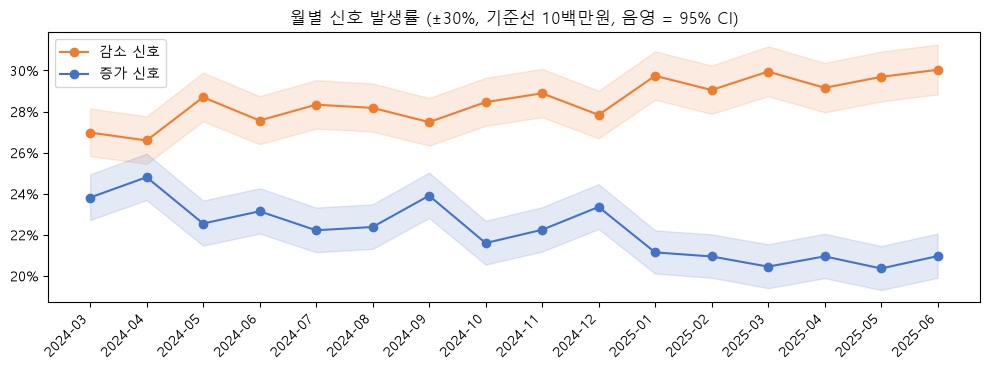

In [7]:
mt = monthly.copy()
for kind in ["감소", "증가"]:
    ci_ = [wilson_ci(k, n) for k, n in zip(mt[kind], mt["위험집합"])]
    mt[f"{kind} 발생률"] = mt[kind] / mt["위험집합"]
    mt[f"{kind} CI 하한"], mt[f"{kind} CI 상한"] = [c[0] for c in ci_], [c[1] for c in ci_]
results["월별_발생률"] = mt

tot_risk = mt["위험집합"].sum()
summary_rate = pd.DataFrame([
    rate_row("감소 신호 (법인-월 전체)", mt["감소"].sum(), tot_risk),
    rate_row("증가 신호 (대조군)", mt["증가"].sum(), tot_risk),
])
by_cal = mt.groupby("월")[["감소", "위험집합"]].sum()
cal_ratio = max_min_ratio(by_cal["감소"] / by_cal["위험집합"])
bias = "판정 불가" if np.isnan(cal_ratio) else ("오염 없음" if cal_ratio < 1.5 else ("경계" if cal_ratio < 2 else "오염 의심"))
note("월평균 감소 발생률", f"{(mt['감소 발생률']).mean():.1%}")
note("감소 ÷ 증가 발생률", f"{mt['감소'].sum() / max(mt['증가'].sum(), 1):.2f}")
note("달별 감소 발생률 최대/최소", f"{cal_ratio:.2f} → {bias}")
results["발생률_요약"] = summary_rate
display(summary_rate)

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(mt))
for kind, col in [("감소", "#ED7D31"), ("증가", "#4472C4")]:
    ax.plot(x, mt[f"{kind} 발생률"], marker="o", color=col, label=f"{kind} 신호")
    ax.fill_between(x, mt[f"{kind} CI 하한"], mt[f"{kind} CI 상한"], color=col, alpha=0.15)
ax.set_xticks(x); ax.set_xticklabels(mt["판정월"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title(f"월별 신호 발생률 (±{THETA:.0%}, 기준선 {BASELINE:g}백만원, 음영 = 95% CI)"); ax.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "02_월별_발생률.png", dpi=150); plt.show()

## 7. 결과 ② 법인 기준 — 이탈 잠재 고객은 몇 개이고, 6개월 뒤 어떻게 됐나

법인당 **첫 감소 신호**만 봅니다.

- 분모: 위험집합에 한 번이라도 든 법인 (판정이 가능했던 법인)
- **정상:** 판정 기간 동안 감소 신호가 한 번도 없음
- **감소 신호 법인**을 6개월 뒤 결과로 나눔: 회복 / 지속저조 / 이탈

→ 발표에서 말할 **"이탈 잠재 고객"의 핵심은 `지속저조`** (계좌는 남아 있는데 거래가 회복되지 않은 법인)입니다.

,구분,수,분모,비율,95% CI 하한,95% CI 상한
0,정상 (신호 없음),2447,8445,0.2898,0.2802,0.2995
1,감소 신호 법인 (전체),5998,8445,0.7102,0.7005,0.7198
2,└ 회복,2693,8445,0.3189,0.3090,0.3289
3,└ 지속저조 (핵심 이탈 잠재),2850,8445,0.3375,0.3275,0.3476
4,└ 이탈,455,8445,0.0539,0.0493,0.0589
5,신호 법인 중 회복,2693,5998,0.4490,0.4364,0.4616
6,신호 법인 중 지속저조,2850,5998,0.4752,0.4625,0.4878
7,신호 법인 중 이탈,455,5998,0.0759,0.0694,0.0828


  · 지속저조 ÷ 이탈: 6.3배


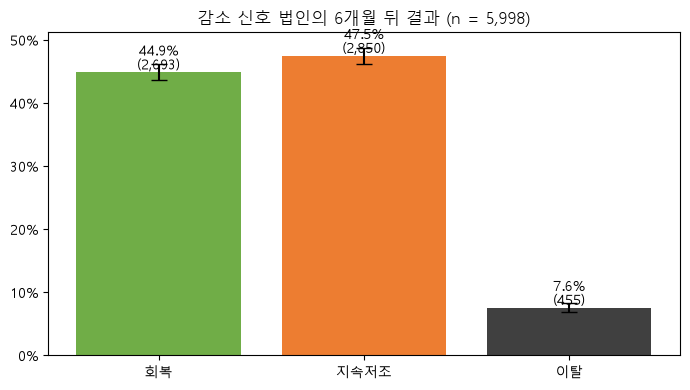

In [8]:
n_base = int(ever_risk.sum())
counts = first["결과"].value_counts()
firm_tbl = pd.DataFrame([
    rate_row("정상 (신호 없음)", n_base - len(first), n_base),
    rate_row("감소 신호 법인 (전체)", len(first), n_base),
    rate_row("  └ 회복", counts.get("회복", 0), n_base),
    rate_row("  └ 지속저조 (핵심 이탈 잠재)", counts.get("지속저조", 0), n_base),
    rate_row("  └ 이탈", counts.get("이탈", 0), n_base),
])
n_first = len(first)
within = pd.DataFrame([rate_row(o, counts.get(o, 0), n_first) for o in ["회복", "지속저조", "이탈"]])
within["구분"] = "신호 법인 중 " + within["구분"]
results["법인기준_결과"] = pd.concat([firm_tbl, within], ignore_index=True)
display(results["법인기준_결과"])

risk_n, churn_n = counts.get("지속저조", 0), counts.get("이탈", 0)
note("지속저조 ÷ 이탈", f"{risk_n / max(churn_n, 1):.1f}배")

fig, ax = plt.subplots(figsize=(7, 4))
w = within.reset_index(drop=True)
ax.bar(["회복", "지속저조", "이탈"], w["비율"], color=["#70AD47", "#ED7D31", "#404040"],
       yerr=[w["비율"] - w["95% CI 하한"], w["95% CI 상한"] - w["비율"]], capsize=6)
for i, r in w.iterrows():
    ax.text(i, r["비율"], f"{r['비율']:.1%}\n({r['수']:,})", ha="center", va="bottom")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title(f"감소 신호 법인의 6개월 뒤 결과 (n = {n_first:,})")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "03_신호후_결과.png", dpi=150); plt.show()

## 8. 결과 ③ 기준값 · 기준선 민감도 — 결론이 기준에 따라 흔들리나

θ(−20/−30/−50%) × 기준선(0 / 10백만원) 6가지 조합을 모두 돌립니다. 확인할 것:

- 조합이 바뀌어도 **"지속저조가 이탈보다 많다"는 구조가 유지되는지**
- 기준선을 넣으면 감소·증가 발생률이 얼마나 줄어드는지 (= 소규모 법인 반올림 노이즈의 크기)

In [9]:
grid_rows = []
for b in BASELINE_LIST:
    for th in THETA_LIST:
        m_, ev_, er_ = run_signals(th, b)
        f_ = ev_.sort_values(["corp", "t"]).drop_duplicates("corp")
        c_ = f_["결과"].value_counts()
        nb = int(er_.sum())
        grid_rows.append({
            "기준값": f"±{th:.0%}", "기준선(백만원)": b, "판정 가능 법인": nb,
            "월평균 감소 발생률": (m_["감소"] / m_["위험집합"]).mean(),
            "월평균 증가 발생률": (m_["증가"] / m_["위험집합"]).mean(),
            "감소 신호 법인 비율": len(f_) / nb if nb else np.nan,
            "지속저조 비율(법인)": c_.get("지속저조", 0) / nb if nb else np.nan,
            "이탈 비율(법인)": c_.get("이탈", 0) / nb if nb else np.nan,
            "신호 중 회복": c_.get("회복", 0) / len(f_) if len(f_) else np.nan,
            "신호 중 지속저조": c_.get("지속저조", 0) / len(f_) if len(f_) else np.nan,
            "신호 중 이탈": c_.get("이탈", 0) / len(f_) if len(f_) else np.nan,
        })
sens = pd.DataFrame(grid_rows)
results["민감도"] = sens
display(sens)

,기준값,기준선(백만원),판정 가능 법인,월평균 감소 발생률,월평균 증가 발생률,감소 신호 법인 비율,지속저조 비율(법인),이탈 비율(법인),신호 중 회복,신호 중 지속저조,신호 중 이탈
0,±20%,0.0000,9916,0.3486,0.2938,0.7963,0.2929,0.0674,0.5476,0.3678,0.0846
1,±30%,0.0000,9916,0.2772,0.2495,0.7055,0.3108,0.0657,0.4664,0.4405,0.0931
2,±50%,0.0000,9916,0.1750,0.1907,0.5205,0.2840,0.0585,0.3420,0.5456,0.1124
3,±20%,10.0000,8445,0.3611,0.2686,0.8032,0.3211,0.0555,0.5310,0.3998,0.0691
4,±30%,10.0000,8445,0.2854,0.2218,0.7102,0.3375,0.0539,0.4490,0.4752,0.0759
5,±50%,10.0000,8445,0.1776,0.1603,0.5221,0.3068,0.0480,0.3205,0.5877,0.0919


## 9. 안전장치 — 신호가 난 달에 따라 회복률이 달라지나

같은 감소 신호라도 신호가 난 달(1~12월)에 따라 회복률 차이가 10%p 이상이면, 결과가 계절에 영향을 받는다는 경고입니다.

In [10]:
ev_m = events.assign(월=[months[t].month for t in events["t"]])
wm = ev_m.groupby("월")["결과"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=["회복", "지속저조", "이탈"], fill_value=0)
wm["신호 수"] = ev_m.groupby("월").size()
spread = (wm["회복"].max() - wm["회복"].min()) * 100 if len(wm) else np.nan
note("달별 회복률 최대−최소", f"{spread:.1f}%p → {'경고' if spread >= 10 else '경고 없음'}")
results["달별_결과"] = wm.reset_index()
display(wm)

  · 달별 회복률 최대−최소: 8.4%p → 경고 없음


결과,회복,지속저조,이탈,신호 수
월,,,,
1,0.3349,0.5734,0.0917,1723
2,0.3380,0.5639,0.0982,1660
3,0.4112,0.5039,0.0849,3169
4,0.3815,0.5263,0.0922,3080
5,0.3760,0.5343,0.0897,3223
6,0.3986,0.5197,0.0817,3196
7,0.3908,0.5433,0.0659,1594
8,0.4165,0.5128,0.0707,1599
9,0.4136,0.5146,0.0718,1574


## 10. 저장

In [11]:
with pd.ExcelWriter(OUTPUT_DIR / "rq1_결과표.xlsx", engine="openpyxl") as w:
    pd.DataFrame(log).to_excel(w, sheet_name="요약", index=False)
    for name, tbl in results.items():
        tbl.to_excel(w, sheet_name=name[:31], index=False)

if SAVE_FIRM_LABEL:
    ids = df["corp"].cat.categories
    lab = pd.DataFrame({KEY_ID: ids, "판정가능": ever_risk})
    lab = lab.merge(first.assign(**{KEY_ID: ids[first["corp"].to_numpy()]})[[KEY_ID, "판정월", "변화율", "결과"]],
                    on=KEY_ID, how="left")
    lab["상태"] = np.where(~lab["판정가능"], "판정 불가", lab["결과"].fillna("정상"))
    lab.to_csv(OUTPUT_DIR / "firm_label_내부전용.csv", index=False, encoding="utf-8-sig")
    print("※ firm_label_내부전용.csv에는 법인ID가 포함되어 있습니다. 외부 공유 금지.")

print(f"저장 완료 → {OUTPUT_DIR.resolve()}")

저장 완료 → C:\pythonim\im뱅크 프로젝트1\output\rq1


## 결과 읽는 순서

1. **3장 데이터 구조:** 빈 달이 있는 데이터인지 확인
2. **6장 발생률 요약:** 매달 몇 %가 감소 신호를 보이는지, 증가 신호와 비교해 출렁임 수준인지
3. **7장 법인 기준:** 감소 신호 법인 중 회복·지속저조·이탈 비율 → **지속저조가 RQ1의 답**
4. **8장 민감도:** 기준을 바꿔도 "지속저조 > 이탈" 구조가 유지되는지
5. **4장, 6장 월 편중, 9장:** 계절 효과가 결과를 오염시키지 않았는지